#  Amazon.in Price Intelligence

##  Part 1 — Install & Import

In [9]:
# Run once to install dependencies
# !pip install selenium webdriver-manager beautifulsoup4 lxml
# !pip install mysql-connector-python pandas numpy matplotlib seaborn

In [10]:
# ── Selenium ────────────────────────────────────────────────────────────────
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException, NoSuchElementException
from webdriver_manager.chrome import ChromeDriverManager

# ── Parsing ─────────────────────────────────────────────────────────────────
from bs4 import BeautifulSoup

# ── Database ─────────────────────────────────────────────────────────────────
import mysql.connector
from mysql.connector import Error

# ── Data ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Utilities ────────────────────────────────────────────────────────────────
import time
import random
import re
import logging
from datetime import datetime

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# ── Logging ──────────────────────────────────────────────────────────────────
logging.basicConfig(
    filename="amazon_scraper.log",
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
log = logging.getLogger(__name__)

print("✅ All imports successful.")

✅ All imports successful.


##  Part 2 — MySQL Configuration


In [11]:
# ── ⚙️  CHANGE THESE to match your MySQL setup ──────────────────────────────
DB_CONFIG = {
    "host":     "localhost",
    "port":     3306,
    "user":     "root",          # your MySQL username
    "password": "    ", # your MySQL password
    "database": "amazon_price_intelligence",
    "charset":  "utf8mb4",
}

# ── Scraper settings ─────────────────────────────────────────────────────────
BASE_URL        = "https://www.amazon.in"
PAGES_PER_QUERY = 20     # ~22 products × 20 pages × 10 queries ≈ 4,400 products
MAX_RETRIES     = 3      # retry failed pages up to 3 times

SEARCH_QUERIES = [
    "Laptop",
    "Smartphone",
    "Headphones",
    "Smart TV",
    "Tablet",
    "Smartwatch",
    "Camera",
    "Refrigerator",
    "Air Conditioner",
    "Washing Machine",
]

print(f"Database         : {DB_CONFIG['database']}")
print(f"Queries          : {len(SEARCH_QUERIES)}")
print(f"Pages per query  : {PAGES_PER_QUERY}")
print(f"Est. products    : ~{len(SEARCH_QUERIES) * PAGES_PER_QUERY * 22:,}")

Database         : amazon_price_intelligence
Queries          : 10
Pages per query  : 20
Est. products    : ~4,400


##  Part 3 — Database Setup (Auto-creates DB + Tables)

In [12]:
def get_connection(use_db: bool = True):
    """Return a MySQL connection. Set use_db=False to connect without selecting a DB."""
    cfg = DB_CONFIG.copy()
    if not use_db:
        cfg.pop("database", None)
    return mysql.connector.connect(**cfg)


def setup_database():
    """
    Creates the database and both tables if they don't already exist.
    Safe to run multiple times — uses IF NOT EXISTS.
    """
    # ── Step 1: Create database ──────────────────────────────────────────
    conn = get_connection(use_db=False)
    cur  = conn.cursor()
    cur.execute(
        f"CREATE DATABASE IF NOT EXISTS `{DB_CONFIG['database']}` "
        f"CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci;"
    )
    conn.commit()
    cur.close()
    conn.close()
    print(f"✅ Database '{DB_CONFIG['database']}' ready.")

    # ── Step 2: Create products table ────────────────────────────────────
    conn = get_connection()
    cur  = conn.cursor()

    cur.execute("""
        CREATE TABLE IF NOT EXISTS products (
            id              INT AUTO_INCREMENT PRIMARY KEY,
            asin            VARCHAR(20)    UNIQUE,
            name            TEXT,
            brand           VARCHAR(100),
            query           VARCHAR(100),
            price_inr       INT,
            original_price  INT,
            discount_pct    DECIMAL(5,2),
            rating          DECIMAL(3,1),
            reviews         INT,
            is_prime        TINYINT(1)     DEFAULT 0,
            is_sponsored    TINYINT(1)     DEFAULT 0,
            price_tier      VARCHAR(20),
            value_score     DECIMAL(10,6),
            url             TEXT,
            page            INT,
            scraped_at      DATETIME,
            updated_at      DATETIME       DEFAULT CURRENT_TIMESTAMP
                                           ON UPDATE CURRENT_TIMESTAMP,
            INDEX idx_query     (query),
            INDEX idx_price     (price_inr),
            INDEX idx_rating    (rating),
            INDEX idx_scraped   (scraped_at)
        ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
    """)

    # ── Step 3: Create scrape_runs log table ─────────────────────────────
    cur.execute("""
        CREATE TABLE IF NOT EXISTS scrape_runs (
            id              INT AUTO_INCREMENT PRIMARY KEY,
            run_started_at  DATETIME,
            run_ended_at    DATETIME,
            queries_scraped TEXT,
            pages_scraped   INT,
            new_rows        INT,
            updated_rows    INT,
            total_in_db     INT,
            status          VARCHAR(20)    DEFAULT 'running'
        ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
    """)

    conn.commit()
    cur.close()
    conn.close()
    print("✅ Tables 'products' and 'scrape_runs' ready.")


setup_database()

✅ Database 'amazon_price_intelligence' ready.
✅ Tables 'products' and 'scrape_runs' ready.


##  Part 4 — Browser Setup

In [13]:
def get_driver(headless: bool = False) -> webdriver.Chrome:
    opts = Options()
    if headless:
        opts.add_argument("--headless=new")
    opts.add_argument("--start-maximized")
    opts.add_argument("--disable-blink-features=AutomationControlled")
    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")
    opts.add_argument("--disable-gpu")
    opts.add_experimental_option("excludeSwitches", ["enable-automation"])
    opts.add_experimental_option("useAutomationExtension", False)

    USER_AGENTS = [
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/138.0.0.0 Safari/537.36",
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36",
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/138.0.0.0 Safari/537.36",
    ]
    opts.add_argument(f"user-agent={random.choice(USER_AGENTS)}")

    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=opts
    )
    driver.execute_script(
        "Object.defineProperty(navigator, 'webdriver', {get: () => undefined})"
    )
    return driver


driver = get_driver(headless=False)   # ← set True to run silently in background
wait   = WebDriverWait(driver, 20)
print("✅ Browser started.")

✅ Browser started.


##  Part 5 — Parser with Feature Engineering

In [14]:
# Known Indian electronics / appliance brands for brand extraction
KNOWN_BRANDS = [
    "Samsung", "Apple", "OnePlus", "Xiaomi", "Redmi", "Realme", "Oppo", "Vivo",
    "Motorola", "Nokia", "HP", "Dell", "Lenovo", "Asus", "Acer", "MSI", "LG",
    "Sony", "Panasonic", "Philips", "Boat", "JBL", "Bose", "Sennheiser",
    "Noise", "Fire-Boltt", "Amazfit", "Whirlpool", "IFB", "Haier", "Godrej",
    "Voltas", "Daikin", "Hitachi", "Blue Star", "Carrier", "TCL", "Hisense",
    "Google", "Nothing", "Poco", "iQOO", "Canon", "Nikon", "Fujifilm",
]

def extract_brand(title: str) -> str | None:
    """Extract brand name from product title."""
    if not title:
        return None
    title_lower = title.lower()
    for brand in KNOWN_BRANDS:
        if brand.lower() in title_lower:
            return brand
    # Fallback: first word is often the brand
    first_word = title.split()[0]
    return first_word if len(first_word) > 1 else None


def get_price_tier(price: int | None) -> str | None:
    """Assign INR price tier label."""
    if price is None:
        return None
    if price < 5000:    return "<₹5K"
    if price < 15000:   return "₹5K-15K"
    if price < 30000:   return "₹15K-30K"
    if price < 60000:   return "₹30K-60K"
    if price < 100000:  return "₹60K-1L"
    return "₹1L+"


def parse_page(html: str, query: str, page: int) -> list[dict]:
    """Parse one Amazon.in results page → list of product dicts."""
    soup     = BeautifulSoup(html, "lxml")
    cards    = soup.find_all("div", {"data-component-type": "s-search-result"})
    products = []

    for card in cards:
        try:
            asin = card.get("data-asin", None)

            # Name
            try:   name = card.h2.text.strip()
            except: name = None

            # URL
            try:
                link_tag = card.find("a", class_="a-link-normal s-no-outline")
                if not link_tag:
                    link_tag = card.h2.find("a")
                link = BASE_URL + link_tag["href"] if link_tag else None
            except: link = None

            # Price
            try:
                price = int(re.sub(r"[^\d]", "",
                            card.find("span", class_="a-price-whole").text))
            except: price = None

            # Original / MRP
            try:
                orig_tag = card.find("span", {"class": "a-price a-text-price"})
                original_price = int(re.sub(r"[^\d]", "",
                    orig_tag.find("span", class_="a-offscreen").text))
            except: original_price = None

            # Discount %
            if price and original_price and original_price > price:
                discount_pct = round((original_price - price) / original_price * 100, 2)
            else:
                discount_pct = None

            # Rating
            try:
                rating_text = card.find("span", class_="a-icon-alt").text
                rating = float(re.search(r"[\d.]+", rating_text).group())
            except: rating = None

            # Reviews
            try:
                rev_tag = card.find("span", {"class": "a-size-base s-underline-text"})
                if not rev_tag:
                    rev_anchor = card.find(
                        "a", {"class": "a-link-normal",
                              "aria-label": re.compile(r"\d+.*rating", re.I)}
                    )
                    if rev_anchor:
                        rev_tag = rev_anchor.find("span", class_="a-size-base")
                reviews = int(re.sub(r"[^\d]", "",
                              rev_tag.text.replace(",", ""))) if rev_tag else None
            except: reviews = None

            is_prime     = card.find("i",    class_="a-icon-prime") is not None
            is_sponsored = bool(card.find("span",
                                string=re.compile(r"Sponsored", re.I)))

            # Derived features
            brand       = extract_brand(name)
            price_tier  = get_price_tier(price)
            value_score = round(rating / price, 6) if rating and price else None

            products.append({
                "asin":           asin,
                "name":           name,
                "brand":          brand,
                "query":          query,
                "price_inr":      price,
                "original_price": original_price,
                "discount_pct":   discount_pct,
                "rating":         rating,
                "reviews":        reviews,
                "is_prime":       int(is_prime),
                "is_sponsored":   int(is_sponsored),
                "price_tier":     price_tier,
                "value_score":    value_score,
                "url":            link,
                "page":           page,
                "scraped_at":     datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            })

        except Exception as e:
            log.warning(f"Card parse error: {e}")
            continue

    return products


print("✅ Parser ready.")

✅ Parser ready.


## Part 6 — MySQL Upsert Function

Uses `INSERT ... ON DUPLICATE KEY UPDATE` so re-running the scraper **updates** existing rows instead of creating duplicates.

In [15]:
UPSERT_SQL = """
    INSERT INTO products
        (asin, name, brand, query, price_inr, original_price, discount_pct,
         rating, reviews, is_prime, is_sponsored, price_tier,
         value_score, url, page, scraped_at)
    VALUES
        (%(asin)s, %(name)s, %(brand)s, %(query)s, %(price_inr)s,
         %(original_price)s, %(discount_pct)s, %(rating)s, %(reviews)s,
         %(is_prime)s, %(is_sponsored)s, %(price_tier)s,
         %(value_score)s, %(url)s, %(page)s, %(scraped_at)s)
    ON DUPLICATE KEY UPDATE
        price_inr      = VALUES(price_inr),
        original_price = VALUES(original_price),
        discount_pct   = VALUES(discount_pct),
        rating         = VALUES(rating),
        reviews        = VALUES(reviews),
        is_prime       = VALUES(is_prime),
        price_tier     = VALUES(price_tier),
        value_score    = VALUES(value_score),
        scraped_at     = VALUES(scraped_at);
"""


def upsert_batch(products: list[dict]) -> tuple[int, int]:
    """
    Upsert a batch of products into MySQL.
    Returns (rows_inserted, rows_updated).
    MySQL ROW_COUNT: 1 = inserted, 2 = updated, 0 = no change.
    """
    if not products:
        return 0, 0

    inserted = updated = 0
    conn = get_connection()
    cur  = conn.cursor()

    try:
        for product in products:
            cur.execute(UPSERT_SQL, product)
            rc = cur.rowcount
            if rc == 1:   inserted += 1
            elif rc == 2: updated  += 1
        conn.commit()
    except Error as e:
        conn.rollback()
        log.error(f"DB upsert error: {e}")
        raise
    finally:
        cur.close()
        conn.close()

    return inserted, updated


def log_run(run_id: int, **kwargs):
    """Update the scrape_runs table row for this run."""
    fields = ", ".join(f"{k} = %s" for k in kwargs)
    values = list(kwargs.values()) + [run_id]
    conn = get_connection()
    cur  = conn.cursor()
    cur.execute(f"UPDATE scrape_runs SET {fields} WHERE id = %s", values)
    conn.commit()
    cur.close()
    conn.close()


def count_db_rows() -> int:
    conn = get_connection()
    cur  = conn.cursor()
    cur.execute("SELECT COUNT(*) FROM products;")
    n = cur.fetchone()[0]
    cur.close()
    conn.close()
    return n


print("✅ DB upsert functions ready.")

✅ DB upsert functions ready.


##  Part 7 — Main Scraping Loop

In [16]:
# ── Register this run in scrape_runs ────────────────────────────────────────
conn = get_connection()
cur  = conn.cursor()
cur.execute("""
    INSERT INTO scrape_runs (run_started_at, queries_scraped, pages_scraped,
                              new_rows, updated_rows, total_in_db, status)
    VALUES (%s, %s, 0, 0, 0, 0, 'running')
""", (datetime.now(), str(SEARCH_QUERIES)))
conn.commit()
RUN_ID = cur.lastrowid
cur.close()
conn.close()
print(f"📋 Scrape run ID: {RUN_ID}")

# ── Counters ─────────────────────────────────────────────────────────────────
total_inserted = 0
total_updated  = 0
total_pages    = 0

# ── Main loop ────────────────────────────────────────────────────────────────
for query in SEARCH_QUERIES:
    print(f"\n🔍 Query: '{query}'")

    driver.get(BASE_URL)
    time.sleep(random.uniform(2, 4))

    try:
        search_box = wait.until(
            EC.presence_of_element_located((By.ID, "twotabsearchtextbox"))
        )
        search_box.clear()
        search_box.send_keys(query)
        search_box.send_keys(Keys.ENTER)
        time.sleep(random.uniform(2, 4))
    except TimeoutException:
        print(f"  ⚠️  Search box not found — skipping '{query}'.")
        continue

    for page in range(1, PAGES_PER_QUERY + 1):

        # ── Retry loop ───────────────────────────────────────────────────
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                wait.until(EC.presence_of_element_located(
                    (By.CSS_SELECTOR, '[data-component-type="s-search-result"]')
                ))
                break   # success
            except TimeoutException:
                if attempt == MAX_RETRIES:
                    print(f"  ❌ Page {page} failed after {MAX_RETRIES} retries.")
                    log.warning(f"{query} page {page}: timeout after {MAX_RETRIES} retries")
                    break
                print(f"  ⟳  Retry {attempt}/{MAX_RETRIES} on page {page}...")
                driver.refresh()
                time.sleep(random.uniform(3, 6))
        else:
            continue

        # Scroll to load lazy elements
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight / 2);")
        time.sleep(0.8)
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(0.5)

        # Parse + save to DB
        products = parse_page(driver.page_source, query, page)
        ins, upd = upsert_batch(products)
        total_inserted += ins
        total_updated  += upd
        total_pages    += 1

        print(f"  Page {page:>3}/{PAGES_PER_QUERY}  "
              f"parsed={len(products)}  "
              f"new={ins}  updated={upd}  "
              f"DB total={count_db_rows():,}")
        log.info(f"{query} p{page}: parsed={len(products)} new={ins} upd={upd}")

        # Next page
        try:
            next_btn = driver.find_element(
                By.CSS_SELECTOR, "a.s-pagination-next"
            )
            next_btn.click()
            time.sleep(random.uniform(2.5, 5.0))
        except NoSuchElementException:
            print(f"  — End of results for '{query}'.")
            break

    time.sleep(random.uniform(6, 12))   # longer pause between queries

# ── Close browser ────────────────────────────────────────────────────────────
driver.quit()

# ── Update run log ───────────────────────────────────────────────────────────
log_run(
    RUN_ID,
    run_ended_at  = datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    pages_scraped = total_pages,
    new_rows      = total_inserted,
    updated_rows  = total_updated,
    total_in_db   = count_db_rows(),
    status        = "completed",
)

print(f"\n{'='*55}")
print(f"  ✅  Scraping complete!")
print(f"  New rows inserted : {total_inserted:,}")
print(f"  Rows updated      : {total_updated:,}")
print(f"  Pages scraped     : {total_pages:,}")
print(f"  Total rows in DB  : {count_db_rows():,}")
print(f"{'='*55}")

📋 Scrape run ID: 15

🔍 Query: 'Laptop'
  Page   1/20  parsed=22  new=1  updated=20  DB total=4,450
  Page   2/20  parsed=25  new=0  updated=25  DB total=4,450
  Page   3/20  parsed=23  new=0  updated=23  DB total=4,450
  Page   4/20  parsed=19  new=0  updated=19  DB total=4,450
  Page   5/20  parsed=19  new=0  updated=19  DB total=4,450
  Page   6/20  parsed=19  new=0  updated=19  DB total=4,450
  Page   7/20  parsed=19  new=0  updated=19  DB total=4,450
  Page   8/20  parsed=19  new=0  updated=19  DB total=4,450
  Page   9/20  parsed=19  new=0  updated=19  DB total=4,450
  Page  10/20  parsed=19  new=0  updated=19  DB total=4,450
  Page  11/20  parsed=19  new=1  updated=18  DB total=4,451
  Page  12/20  parsed=19  new=0  updated=19  DB total=4,451
  Page  13/20  parsed=19  new=0  updated=19  DB total=4,451
  Page  14/20  parsed=19  new=0  updated=19  DB total=4,451
  Page  15/20  parsed=19  new=0  updated=19  DB total=4,451
  Page  16/20  parsed=19  new=0  updated=19  DB total=4,451
 

## 📥 Part 8 — Load from MySQL into Pandas

In [18]:
def query_db(sql: str) -> pd.DataFrame:
    """Run any SELECT query and return a DataFrame."""
    conn = get_connection()
    df   = pd.read_sql(sql, conn)
    conn.close()
    return df


# Load full products table
df = query_db("SELECT * FROM products;")

print(f"Rows loaded from MySQL : {len(df):,}")
print(f"Columns                : {list(df.columns)}")
df.head(3)

C:\Users\yamni\AppData\Local\Temp\ipykernel_28172\4012681103.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df   = pd.read_sql(sql, conn)


Rows loaded from MySQL : 4,663
Columns                : ['id', 'asin', 'name', 'brand', 'query', 'price_inr', 'original_price', 'discount_pct', 'rating', 'reviews', 'is_prime', 'is_sponsored', 'price_tier', 'value_score', 'url', 'page', 'scraped_at', 'updated_at']


,id,asin,name,brand,query,price_inr,original_price,discount_pct,rating,reviews,is_prime,is_sponsored,price_tier,value_score,url,page,scraped_at,updated_at
0,1,B0FZHS7V49,"acer Aspire Lite Intel Core 5-210H Processor, ...",Acer,Laptop,64490.0,99999.0,35.51,2.9,None,0,1,₹60K-1L,0.000045,https://www.amazon.in/sspa/click?ie=UTF8&spc=M...,1,2026-07-27 01:17:42,2026-07-27 01:17:42
1,2,B0G2BHDDB8,"HP 14 Smartchoice, Intel Core Ultra 5 125H 12 ...",HP,Laptop,77990.0,81143.0,3.89,3.5,None,0,1,₹60K-1L,0.000045,https://www.amazon.in/sspa/click?ie=UTF8&spc=M...,1,2026-07-27 21:56:01,2026-07-27 21:56:01
2,3,B0F4R6GXWJ,"HP 15 Smartchoice, 13th Gen Intel Core i3-1315...",HP,Laptop,49990.0,5211417.0,99.04,4.1,None,0,0,₹30K-60K,0.000082,https://www.amazon.in/HP-i3-1315U-Anti-Glare-M...,1,2026-07-27 21:55:50,2026-07-27 21:55:50


## 🧹 Part 9 — Cleaning & Feature Engineering

In [19]:
df.shape

(4663, 18)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4663 entries, 0 to 4662
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              4663 non-null   int64         
 1   asin            4663 non-null   object        
 2   name            4663 non-null   object        
 3   brand           4648 non-null   object        
 4   query           4663 non-null   object        
 5   price_inr       4414 non-null   float64       
 6   original_price  4129 non-null   float64       
 7   discount_pct    3965 non-null   float64       
 8   rating          3822 non-null   float64       
 9   reviews         0 non-null      object        
 10  is_prime        4663 non-null   int64         
 11  is_sponsored    4663 non-null   int64         
 12  price_tier      4414 non-null   object        
 13  value_score     3616 non-null   float64       
 14  url             4663 non-null   object        
 15  page

In [21]:
df.isnull().sum()

id                   0
asin                 0
name                 0
brand               15
query                0
price_inr          249
original_price     534
discount_pct       698
rating             841
reviews           4663
is_prime             0
is_sponsored         0
price_tier         249
value_score       1047
url                  0
page                 0
scraped_at           0
updated_at           0
dtype: int64

In [22]:
df = df.dropna(subset=["name"])

In [23]:
df["rating"]= pd.to_numeric(df["rating"],errors="coerce").clip(0, 5)

In [24]:
def get_rating_status(rating):
    if pd.isna(rating):
        return "Unrated"
    elif rating >= 4.5:
        return "Excellent"
    elif rating >= 4.0:
        return "Very Good"
    elif rating >= 3.5:
        return "Good"
    elif rating >= 3.0:
        return "Average"
    else:
        return "Poor"

df["rating_status"] = df["rating"].apply(get_rating_status)

In [25]:
def extract(title):
    return title.split()[0]

mask = df["brand"].isna()

df.loc[mask, "brand"] = df.loc[mask, "name"].apply(extract)

In [26]:
#Fill original_price with price_inr
mask = (
    df["original_price"].isna() &
    df["price_inr"].notna()
)

df.loc[mask, "original_price"] = df.loc[mask, "price_inr"]

In [27]:
#Fill discount_pct with 0
mask = df["discount_pct"].isna()

df.loc[mask, "discount_pct"] = 0

In [28]:
# Fill missing discount_pct using price_inr and original_price
mask = (
    df["discount_pct"].isna() &
    df["price_inr"].notna() &
    df["original_price"].notna()
)

df.loc[mask, "discount_pct"] = (
    (df.loc[mask, "original_price"] - df.loc[mask, "price_inr"])
    / df.loc[mask, "original_price"] * 100
).round(2)

In [29]:
df.drop(columns=["reviews"], inplace=True)

In [30]:
df["price_tier"] = df["price_tier"].fillna("Unknown")

In [31]:
df[["price_inr", "original_price", "discount_pct"]].isna().sum()

price_inr         249
original_price    249
discount_pct        0
dtype: int64

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4663 entries, 0 to 4662
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              4663 non-null   int64         
 1   asin            4663 non-null   object        
 2   name            4663 non-null   object        
 3   brand           4663 non-null   object        
 4   query           4663 non-null   object        
 5   price_inr       4414 non-null   float64       
 6   original_price  4414 non-null   float64       
 7   discount_pct    4663 non-null   float64       
 8   rating          3822 non-null   float64       
 9   is_prime        4663 non-null   int64         
 10  is_sponsored    4663 non-null   int64         
 11  price_tier      4663 non-null   object        
 12  value_score     3616 non-null   float64       
 13  url             4663 non-null   object        
 14  page            4663 non-null   int64         
 15  scra

##  Part 10 — SQL Business Insight Queries

These are the kind of queries you'd write in a Google DA interview or Looker/BigQuery environment.

In [34]:
# ===========================
# AMAZON PRODUCT SQL ANALYSIS
# ===========================

# Q1
print("\n── Q1: Category-wise Product Summary ──")
print(query_db("""
SELECT
    query AS category,
    COUNT(*) AS total_products,
    ROUND(AVG(price_inr),0) AS avg_price_inr,
    ROUND(AVG(rating),2) AS avg_rating,
    ROUND(AVG(discount_pct),1) AS avg_discount_pct,
    SUM(is_prime) AS prime_products
FROM products
WHERE price_inr IS NOT NULL
GROUP BY query
ORDER BY avg_price_inr DESC;
""").to_string(index=False))


# Q2
print("\n── Q2: Top 10 Best Value Products ──")
print(query_db("""
SELECT
    asin,
    LEFT(name,60) AS product_name,
    brand,
    query AS category,
    price_inr,
    rating,
    value_score
FROM products
WHERE rating >= 4.0
AND price_inr IS NOT NULL
AND value_score IS NOT NULL
ORDER BY value_score DESC
LIMIT 10;
""").to_string(index=False))


# Q3
print("\n── Q3: Prime vs Non-Prime Comparison ──")
print(query_db("""
SELECT
    CASE
        WHEN is_prime=1 THEN 'Prime'
        ELSE 'Non-Prime'
    END AS membership,

    COUNT(*) AS total_products,
    ROUND(AVG(price_inr),0) AS avg_price,
    ROUND(AVG(rating),2) AS avg_rating,
    ROUND(AVG(discount_pct),1) AS avg_discount

FROM products
GROUP BY is_prime;
""").to_string(index=False))


# Q4
print("\n── Q4: Most Common Brands by Category ──")
print(query_db("""
SELECT
    query AS category,
    brand,
    COUNT(*) AS product_count,
    ROUND(AVG(price_inr),0) AS avg_price,
    ROUND(AVG(rating),2) AS avg_rating

FROM products

WHERE brand IS NOT NULL
AND price_inr IS NOT NULL

GROUP BY query,brand

ORDER BY query,product_count DESC

LIMIT 30;
""").to_string(index=False))


# Q5
print("\n── Q5: Top 10 Highest Discount Products ──")
print(query_db("""
SELECT
    LEFT(name,60) AS product_name,
    brand,
    original_price,
    price_inr,
    discount_pct

FROM products

WHERE discount_pct IS NOT NULL

ORDER BY discount_pct DESC

LIMIT 10;
""").to_string(index=False))


# Q6
print("\n── Q6: Top 10 Most Expensive Products ──")
print(query_db("""
SELECT
    LEFT(name,60) AS product_name,
    brand,
    query,
    price_inr,
    rating

FROM products

WHERE price_inr IS NOT NULL

ORDER BY price_inr DESC

LIMIT 10;
""").to_string(index=False))


# Q7
print("\n── Q7: Top 10 Cheapest Products ──")
print(query_db("""
SELECT
    LEFT(name,60) AS product_name,
    brand,
    query,
    price_inr,
    rating

FROM products

WHERE price_inr IS NOT NULL

ORDER BY price_inr ASC

LIMIT 10;
""").to_string(index=False))


# Q8
print("\n── Q8: Brand-wise Price Analysis ──")
print(query_db("""
SELECT
    brand,
    COUNT(*) AS total_products,
    ROUND(AVG(price_inr),0) AS avg_price,
    ROUND(AVG(rating),2) AS avg_rating

FROM products

WHERE brand IS NOT NULL
AND price_inr IS NOT NULL

GROUP BY brand

HAVING COUNT(*)>=5

ORDER BY avg_price DESC;
""").to_string(index=False))


# Q9
print("\n── Q9: Price Tier Distribution ──")
print(query_db("""
SELECT
    price_tier,
    COUNT(*) AS total_products,
    ROUND(AVG(price_inr),0) AS avg_price,
    ROUND(AVG(rating),2) AS avg_rating

FROM products

WHERE price_tier IS NOT NULL

GROUP BY price_tier

ORDER BY avg_price DESC;
""").to_string(index=False))


# Q10
print("\n── Q10: Category-wise Prime Percentage ──")
print(query_db("""
SELECT
    query AS category,
    COUNT(*) AS total_products,
    SUM(is_prime) AS prime_products,

    ROUND(
        SUM(is_prime)*100.0/COUNT(*),
        2
    ) AS prime_percentage

FROM products

GROUP BY query

ORDER BY prime_percentage DESC;
""").to_string(index=False))


# Q11
print("\n── Q11: Scrape Run History ──")
print(query_db("""
SELECT *
FROM scrape_runs
ORDER BY id DESC
LIMIT 5;
""").to_string(index=False))


── Q1: Category-wise Product Summary ──


C:\Users\yamni\AppData\Local\Temp\ipykernel_28172\4012681103.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df   = pd.read_sql(sql, conn)


       category  total_products  avg_price_inr  avg_rating  avg_discount_pct  prime_products
         Laptop             410       114979.0        3.78              25.4             0.0
       Smart TV             432        44760.0        3.96              44.0             0.0
Air Conditioner             275        41592.0        3.77              37.9             0.0
     Smartphone             414        39379.0        4.00              23.4             0.0
   Refrigerator             302        38522.0        3.94              28.5             0.0
         Tablet             478        29594.0        4.14              33.8             0.0
Washing Machine             327        18158.0        4.15              32.4             0.0
         Camera             606        16076.0        3.67              52.2             0.0
     Headphones             591         5835.0        3.86              57.9             0.0
     Smartwatch             579         4809.0        3.85            

C:\Users\yamni\AppData\Local\Temp\ipykernel_28172\4012681103.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df   = pd.read_sql(sql, conn)
C:\Users\yamni\AppData\Local\Temp\ipykernel_28172\4012681103.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df   = pd.read_sql(sql, conn)
C:\Users\yamni\AppData\Local\Temp\ipykernel_28172\4012681103.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df   = pd.read_sql(sql, conn)


       category         brand  product_count  avg_price  avg_rating
Air Conditioner     Blue Star             31    45917.0        3.89
Air Conditioner        Voltas             30    41071.0        3.76
Air Conditioner        Daikin             26    45575.0        4.00
Air Conditioner     Panasonic             25    46121.0        3.96
Air Conditioner            LG             20    41337.0        3.96
Air Conditioner       Hitachi             20    39292.0        3.86
Air Conditioner         Haier             16    41454.0        3.46
Air Conditioner        Godrej             16    42301.0        3.53
Air Conditioner       Samsung             11    38341.0        3.84
Air Conditioner     Whirlpool             10    33649.0        2.71
Air Conditioner       Carrier             10    39809.0        4.01
Air Conditioner       GENERAL              9    67571.0        3.68
Air Conditioner         Lloyd              7    43738.0        3.39
Air Conditioner           IFB              6    

C:\Users\yamni\AppData\Local\Temp\ipykernel_28172\4012681103.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df   = pd.read_sql(sql, conn)
C:\Users\yamni\AppData\Local\Temp\ipykernel_28172\4012681103.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df   = pd.read_sql(sql, conn)
C:\Users\yamni\AppData\Local\Temp\ipykernel_28172\4012681103.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df   = pd.read_sql(sql, conn)
C:\Users\yamni\AppData\Local\Temp\ipykernel_28172\4012681103.py:4: UserWarning: pandas only supports

     brand  total_products  avg_price  avg_rating
 Alienware               5   494099.0        3.53
      Asus              36   247410.0        4.15
 Microsoft               7   170017.0        4.16
       MSI              11   135084.0        3.64
     Nikon               7   107070.0        4.38
      Dell              29    99255.0        3.27
    Garmin               6    94941.0        4.44
   Hisense              21    92189.0        4.00
        HP             129    91375.0        3.71
    Lenovo             158    88875.0        4.01
       BIG               6    87767.0        4.57
     Canon              16    84863.0        4.28
Electrolux              14    78589.0        4.46
     Apple              42    76344.0        4.32
      Sony              78    71402.0        4.20
   Toshiba               9    70260.0        3.91
   GENERAL               9    67571.0        3.68
      Vivo              57    61960.0        4.14
 Panasonic              34    56931.0        3.97


C:\Users\yamni\AppData\Local\Temp\ipykernel_28172\4012681103.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df   = pd.read_sql(sql, conn)
C:\Users\yamni\AppData\Local\Temp\ipykernel_28172\4012681103.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df   = pd.read_sql(sql, conn)
C:\Users\yamni\AppData\Local\Temp\ipykernel_28172\4012681103.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df   = pd.read_sql(sql, conn)


 id      run_started_at        run_ended_at                                                                                                                            queries_scraped  pages_scraped  new_rows  updated_rows  total_in_db    status
 15 2026-07-27 21:53:35 2026-07-27 22:31:34 ['Laptop', 'Smartphone', 'Headphones', 'Smart TV', 'Tablet', 'Smartwatch', 'Camera', 'Refrigerator', 'Air Conditioner', 'Washing Machine']            200       214          3550         4663 completed
 14 2026-07-27 21:20:34                 NaT ['Laptop', 'Smartphone', 'Headphones', 'Smart TV', 'Tablet', 'Smartwatch', 'Camera', 'Refrigerator', 'Air Conditioner', 'Washing Machine']              0         0             0            0   running
 13 2026-07-27 21:18:54                 NaT ['Laptop', 'Smartphone', 'Headphones', 'Smart TV', 'Tablet', 'Smartwatch', 'Camera', 'Refrigerator', 'Air Conditioner', 'Washing Machine']              0         0             0            0   running
 12 2026-07-27 21:18

## 📊 Part 11 — EDA Visualisations

In [36]:
# ── 11.1 Overview ─────────────────────────────────────────────────────────
print("=" * 58)
print(f"  Total products   : {len(df):>10,}")
print(f"  Categories       : {df['query'].nunique():>10}")
print(f"  Unique brands    : {df['brand'].nunique():>10}")
print(f"  Price coverage   : {df['price_inr'].notna().mean():>9.1%}")
print(f"  Rating coverage  : {df['rating'].notna().mean():>9.1%}")
print(f"  Prime share      : {df['is_prime'].mean():>9.1%}")
print(f"  Sponsored share  : {df['is_sponsored'].mean():>9.1%}")
print(f"  With discount    : {df['discount_pct'].notna().mean():>9.1%}")
print("=" * 58)

  Total products   :      4,663
  Categories       :         10
  Unique brands    :        652
  Price coverage   :     94.7%
  Rating coverage  :     82.0%
  Prime share      :      0.0%
  Sponsored share  :     23.5%
  With discount    :    100.0%


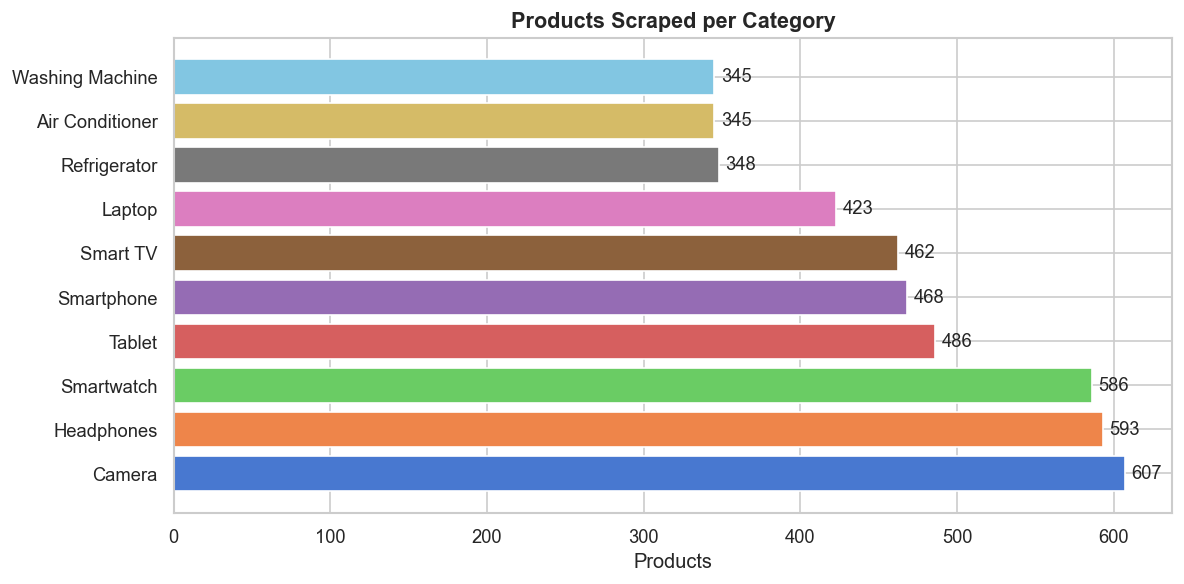

In [37]:
# ── 11.2 Products per category ────────────────────────────────────────────
counts = df["query"].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(counts.index, counts.values,
               color=sns.color_palette("muted", len(counts)))
ax.bar_label(bars, fmt="{:,.0f}", padding=4)
ax.set_xlabel("Products")
ax.set_title("Products Scraped per Category", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_01_category_counts.png", dpi=150)
plt.show()

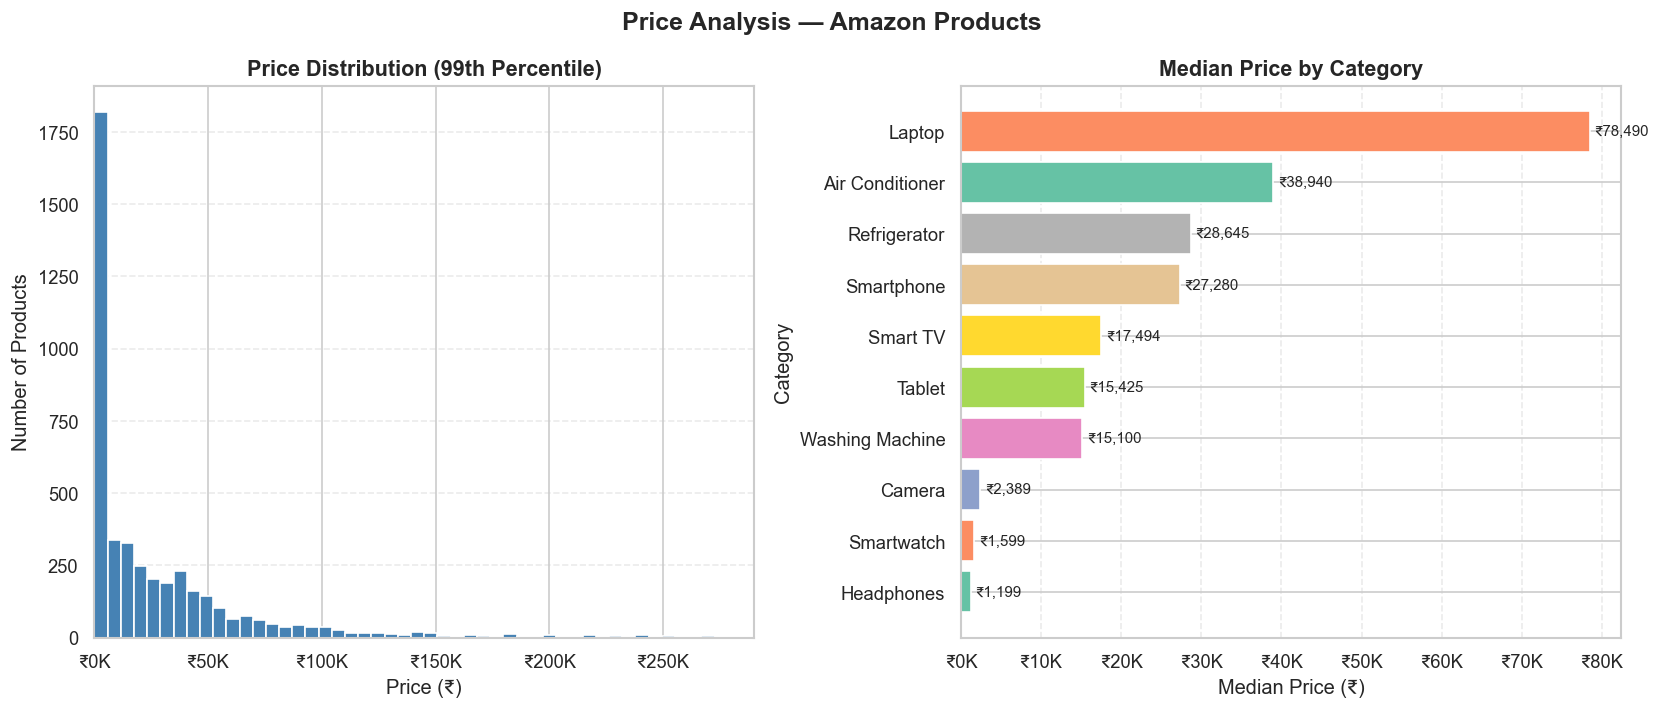

In [40]:
# ── 11.3 Price Distribution & Median Price by Category ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram (99th percentile to avoid extreme outliers)
price = df["price_inr"].dropna()

upper = price.quantile(0.99)

axes[0].hist(
    price[price <= upper],
    bins=50,
    color="steelblue",
    edgecolor="white"
)

axes[0].set_xlim(0, upper)

axes[0].set_title(
    "Price Distribution (99th Percentile)",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Price (₹)")
axes[0].set_ylabel("Number of Products")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₹{x/1000:.0f}K")
)

# Median Price by Category
median_price = (
    df.groupby("query")["price_inr"]
      .median()
      .sort_values()
)

bars = axes[1].barh(
    median_price.index,
    median_price.values,
    color=sns.color_palette("Set2", len(median_price))
)

axes[1].bar_label(
    bars,
    labels=[f"₹{x:,.0f}" for x in median_price.values],
    padding=3,
    fontsize=9
)

axes[1].set_title(
    "Median Price by Category",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("Median Price (₹)")
axes[1].set_ylabel("Category")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₹{x/1000:.0f}K")
)

plt.suptitle(
    "Price Analysis — Amazon Products",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "plot_02_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

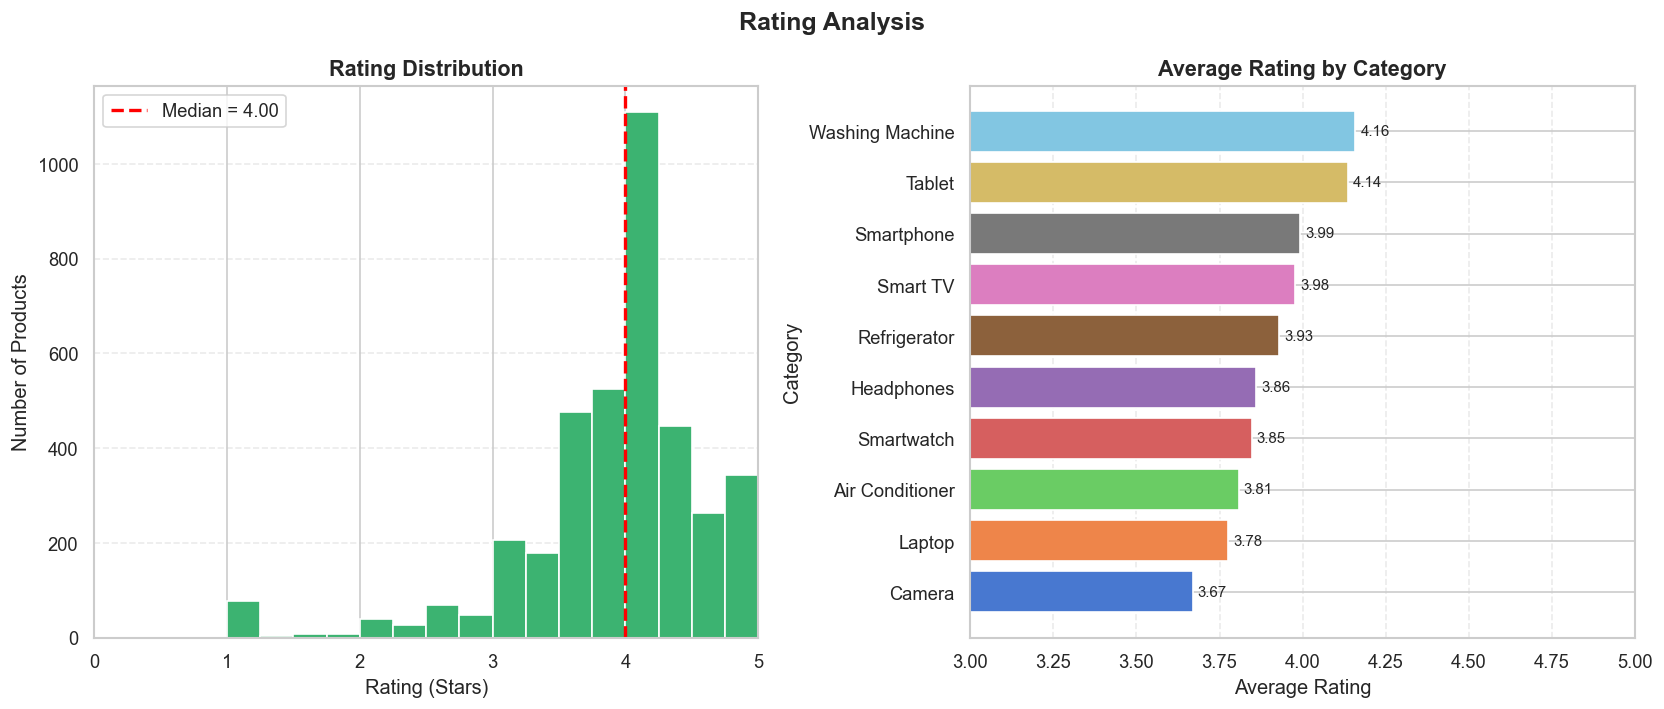

In [46]:
# ── 11.4 Rating Analysis ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Rating Distribution
df["rating"].dropna().hist(
    bins=np.arange(0, 5.25, 0.25),
    ax=axes[0],
    color="mediumseagreen",
    edgecolor="white"
)

median_rating = df["rating"].median()

axes[0].axvline(
    median_rating,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_rating:.2f}"
)

axes[0].set_title(
    "Rating Distribution",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Rating (Stars)")
axes[0].set_ylabel("Number of Products")
axes[0].set_xlim(0, 5)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].legend()

# Average Rating by Category
avg_rating = (
    df.groupby("query")["rating"]
      .mean()
      .sort_values()
)

bars = axes[1].barh(
    avg_rating.index,
    avg_rating.values,
    color=sns.color_palette("muted", len(avg_rating))
)

axes[1].bar_label(
    bars,
    fmt="%.2f",
    padding=3,
    fontsize=9
)

axes[1].set_title(
    "Average Rating by Category",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("Average Rating")
axes[1].set_ylabel("Category")
axes[1].set_xlim(3, 5)
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle(
    "Rating Analysis",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "plot_03_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

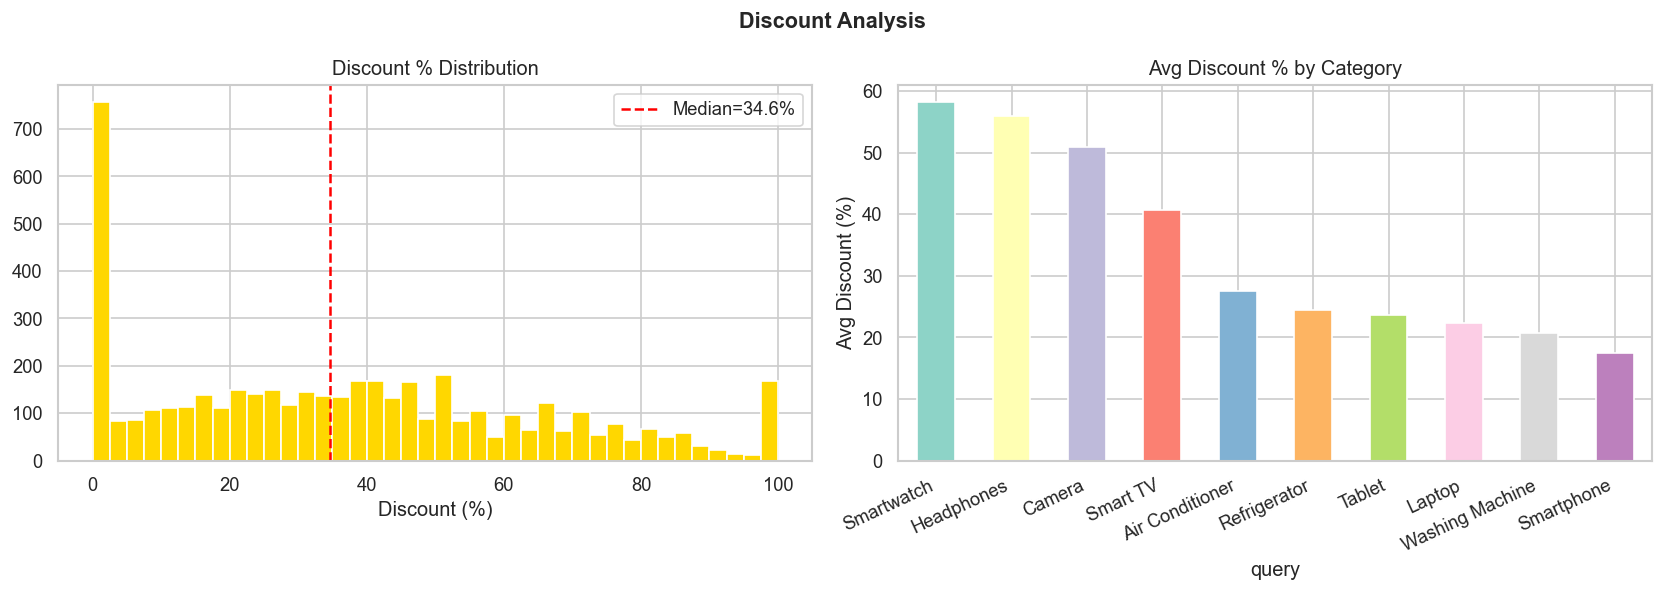

In [47]:
# ── 11.5 Discount analysis ────────────────────────────────────────────────
disc = df[df["discount_pct"].notna()]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disc["discount_pct"].hist(bins=40, ax=axes[0],
                           color="gold", edgecolor="white")
axes[0].axvline(disc["discount_pct"].median(), color="red",
                linestyle="--",
                label=f"Median={disc['discount_pct'].median():.1f}%")
axes[0].set_title("Discount % Distribution")
axes[0].set_xlabel("Discount (%)")
axes[0].legend()

disc.groupby("query")["discount_pct"].mean() \
    .sort_values(ascending=False) \
    .plot(kind="bar", ax=axes[1],
          color=sns.color_palette("Set3", disc["query"].nunique()))
axes[1].set_title("Avg Discount % by Category")
axes[1].set_ylabel("Avg Discount (%)")
axes[1].set_xticklabels(axes[1].get_xticklabels(),
                         rotation=25, ha="right")

plt.suptitle("Discount Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_04_discount.png", dpi=150)
plt.show()

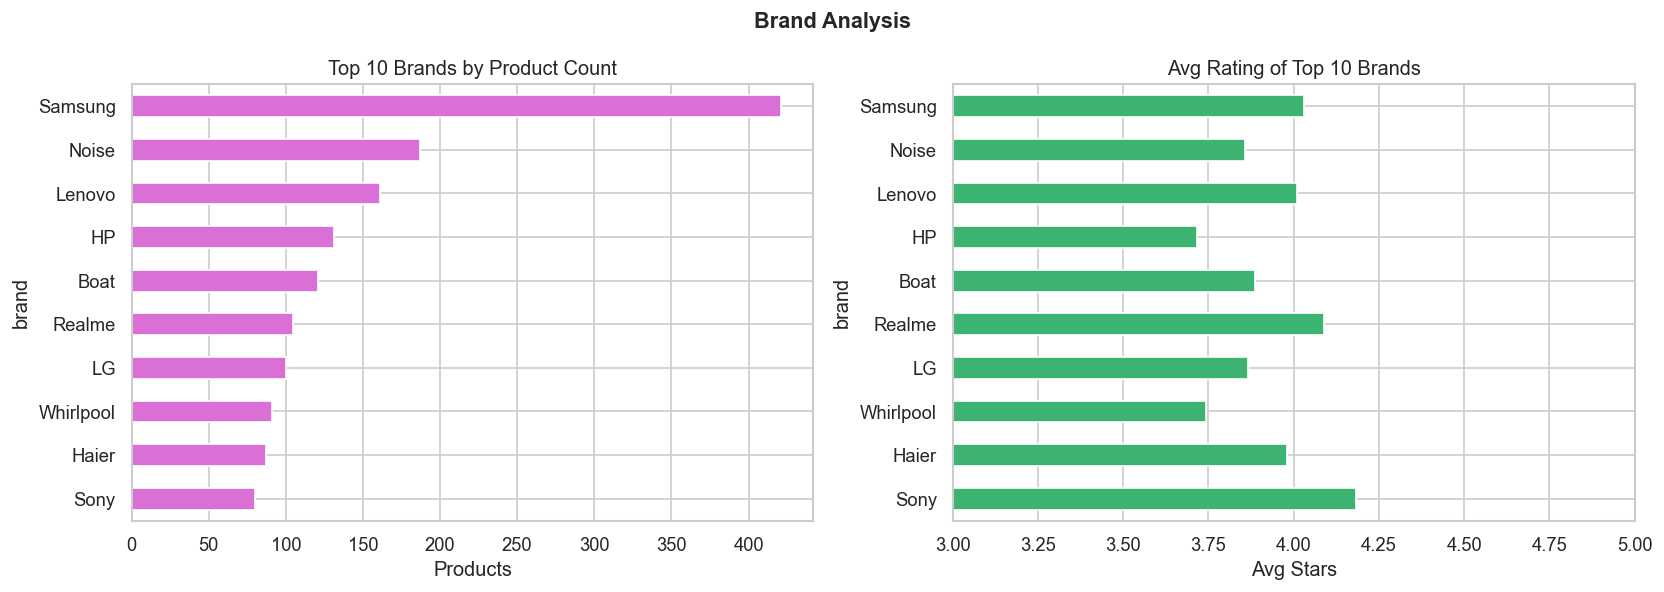

In [53]:
# ── 11.6 Top 10 brands by product count ──────────────────────────────────
top_brands = (
    df[df["brand"].notna()]
    .groupby("brand")
    .agg(count=("asin","count"), avg_rating=("rating","mean"),
         avg_price=("price_inr","mean"))
    .nlargest(10, "count")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_brands["count"].plot(kind="barh", ax=axes[0], color="orchid")
axes[0].set_title("Top 10 Brands by Product Count")
axes[0].set_xlabel("Products")
axes[0].invert_yaxis()

top_brands["avg_rating"].plot(kind="barh", ax=axes[1],
                               color="mediumseagreen")
axes[1].set_title("Avg Rating of Top 10 Brands")
axes[1].set_xlabel("Avg Stars")
axes[1].set_xlim(3, 5)
axes[1].invert_yaxis()

plt.suptitle("Brand Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_06_brands.png", dpi=150)
plt.show()

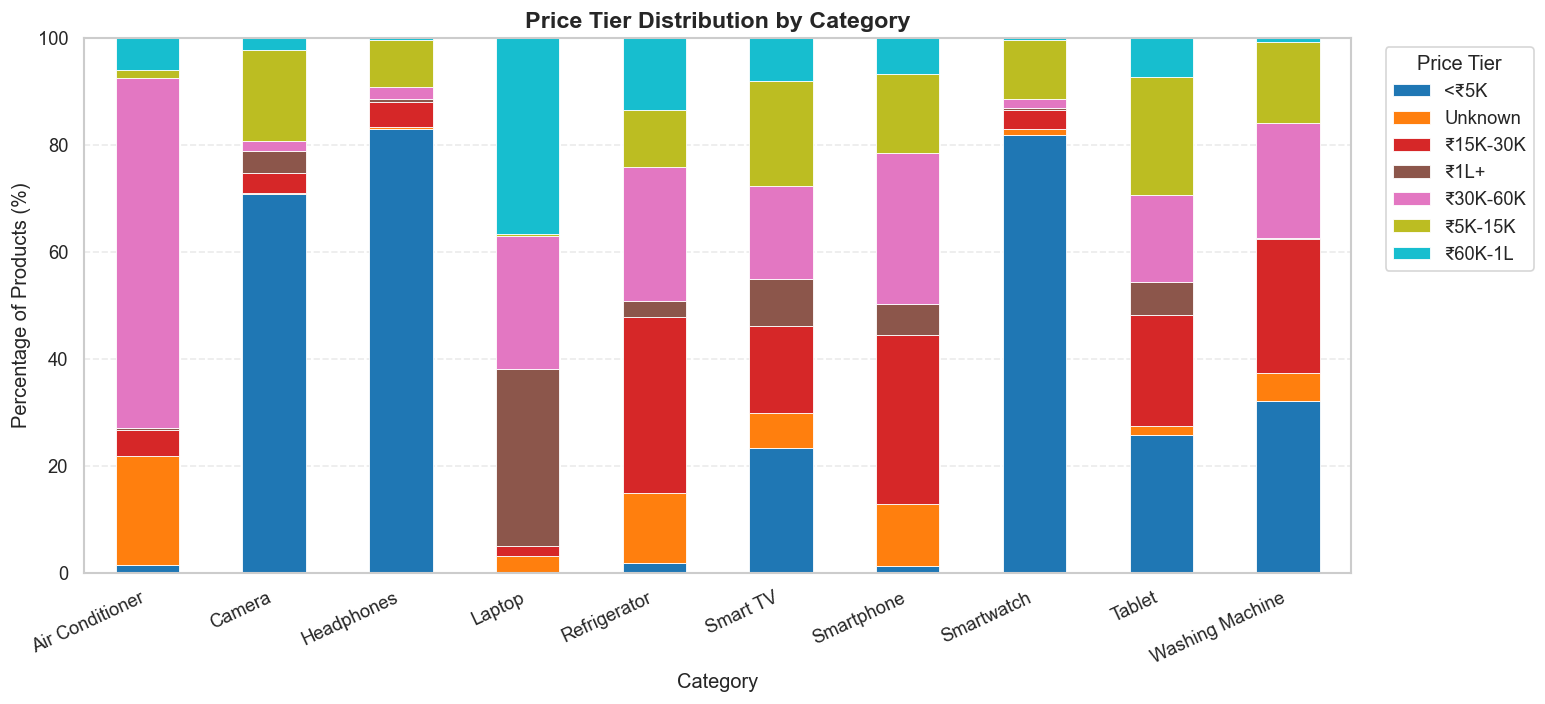

In [54]:
# ── 11.6 Price Tier Distribution by Category ───────────────────────────────

tier_pct = (
    df.groupby(["query", "price_tier"], observed=True)
      .size()
      .unstack(fill_value=0)
      .pipe(lambda x: x.div(x.sum(axis=1), axis=0) * 100)
)

fig, ax = plt.subplots(figsize=(13, 6))

tier_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="tab10",
    edgecolor="white",
    linewidth=0.5
)

ax.set_title(
    "Price Tier Distribution by Category",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Category")
ax.set_ylabel("Percentage of Products (%)")

ax.set_xticklabels(
    tier_pct.index,
    rotation=25,
    ha="right"
)

ax.set_ylim(0, 100)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax.legend(
    title="Price Tier",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "plot_07_price_tier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

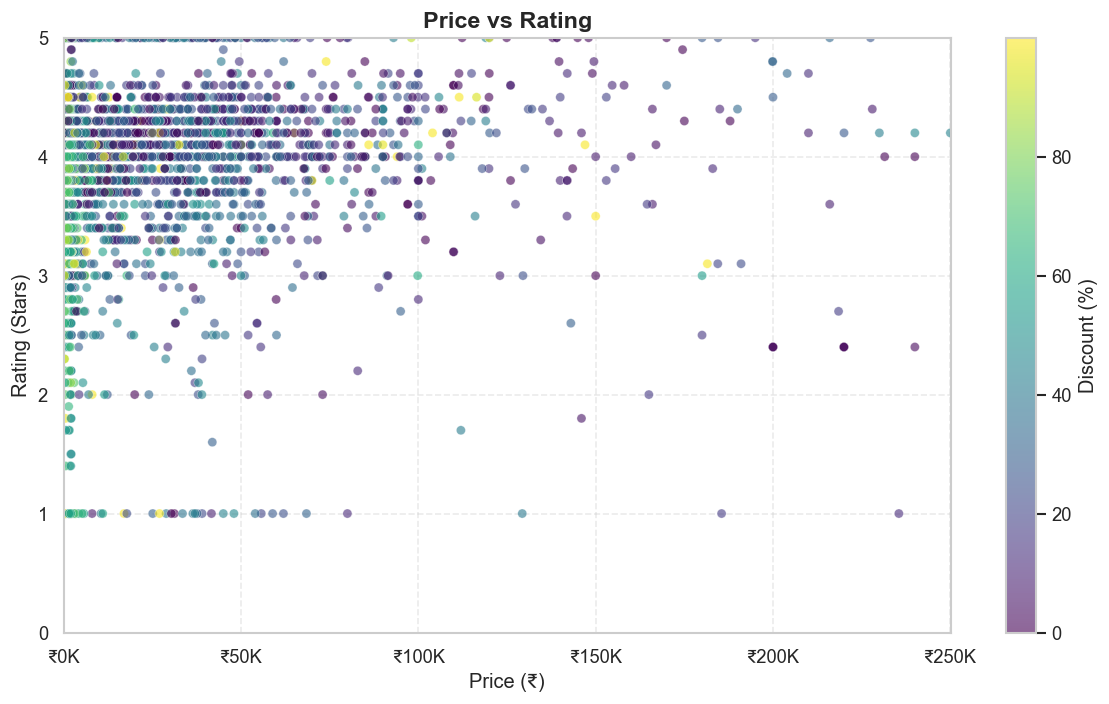

In [55]:
# ── 11.7 Rating vs Price Scatter Plot ─────────────────────────────────────

sample = df.dropna(subset=["price_inr", "rating"]).sample(
    n=min(3000, len(df.dropna(subset=["price_inr", "rating"]))),
    random_state=42
)

# Remove only extreme outliers for visualization
upper = sample["price_inr"].quantile(0.99)
sample_plot = sample[sample["price_inr"] <= upper]

fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    sample_plot["price_inr"],
    sample_plot["rating"],
    c=sample_plot["discount_pct"].fillna(0),
    cmap="viridis",
    s=30,
    alpha=0.6,
    edgecolors="white",
    linewidth=0.3
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Discount (%)")

ax.set_title(
    "Price vs Rating",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Price (₹)")
ax.set_ylabel("Rating (Stars)")

ax.set_xlim(0, upper)
ax.set_ylim(0, 5)

ax.grid(linestyle="--", alpha=0.4)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₹{x/1000:.0f}K")
)

plt.tight_layout()

plt.savefig(
    "plot_08_rating_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

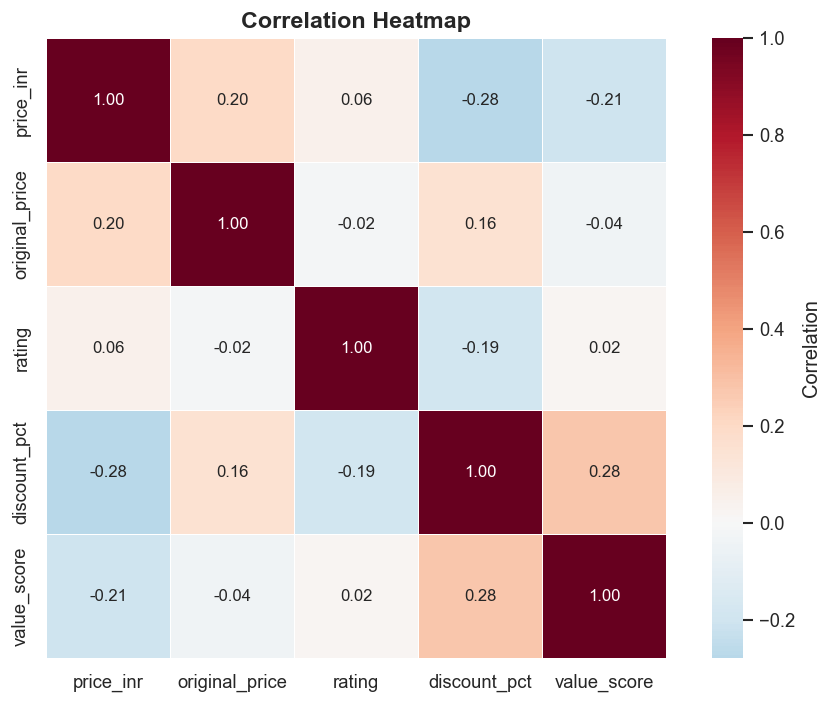

In [56]:
# ── 11.8 Correlation Heatmap ─────────────────────────────────────────────

corr = (
    df[
        [
            "price_inr",
            "original_price",
            "rating",
            "discount_pct",
            "value_score"
        ]
    ]
    .corr(numeric_only=True)
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
    annot_kws={"size": 10},
    ax=ax
)

ax.set_title(
    "Correlation Heatmap",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "plot_09_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📝 Part 12 — Key Business Insights

In [60]:
# ── 12. Key Business Insights ─────────────────────────────────────────────

g = df.groupby("query")

print("=" * 70)
print("KEY BUSINESS INSIGHTS — Amazon.in Price Intelligence")
print("=" * 70)

print(f"""
Total products analyzed     : {len(df):,}
Categories tracked          : {df['query'].nunique()}
Unique brands               : {df['brand'].nunique()}

Most expensive category     : {g['price_inr'].median().idxmax()}
   Median price             : ₹{g['price_inr'].median().max():,.0f}

Most affordable category    : {g['price_inr'].median().idxmin()}
   Median price             : ₹{g['price_inr'].median().min():,.0f}

Highest rated category      : {g['rating'].mean().idxmax()}
   Average rating           : {g['rating'].mean().max():.2f} ⭐

Highest discount category   : {g['discount_pct'].mean().idxmax()}
   Average discount         : {g['discount_pct'].mean().max():.1f}%

Best value category         : {g['value_score'].mean().idxmax()}
   Average value score      : {g['value_score'].mean().max():.6f}

Average product price       : ₹{df['price_inr'].mean():,.0f}
Median product price        : ₹{df['price_inr'].median():,.0f}

Average product rating      : {df['rating'].mean():.2f} ⭐
Average discount            : {df['discount_pct'].mean():.1f}%

Products with discounts     : {df['discount_pct'].notna().mean():.1%}
Sponsored products          : {df['is_sponsored'].mean():.1%}
""")

print("=" * 70)

KEY BUSINESS INSIGHTS — Amazon.in Price Intelligence

Total products analyzed     : 4,663
Categories tracked          : 10
Unique brands               : 652

Most expensive category     : Laptop
   Median price             : ₹78,490

Most affordable category    : Headphones
   Median price             : ₹1,199

Highest rated category      : Washing Machine
   Average rating           : 4.16 ⭐

Highest discount category   : Smartwatch
   Average discount         : 58.1%

Best value category         : Smartwatch
   Average value score      : 0.004140

Average product price       : ₹32,150
Median product price        : ₹12,500

Average product rating      : 3.90 ⭐
Average discount            : 36.7%

Products with discounts     : 100.0%
Sponsored products          : 23.5%



# Part 13 - MySQL Administrative Queries

These SQL queries were executed in **MySQL Workbench** to validate the database, inspect product statistics, analyze pricing trends, and verify the quality of the scraped Amazon dataset.

The queries include:

- Total products in the database
- Products by category
- Price summary by category
- Highest discounted products
- Highest rated products
- Best value products
- Rating status distribution
- Price tier distribution
- Brand-wise average pricing
- Scrape history

> **Note:** These queries are intended to be executed in MySQL Workbench and are included here for documentation purposes.

In [62]:
-- ==========================================================
-- Part 13 — Useful MySQL Admin Queries
-- Amazon.in Price Intelligence Platform
-- ==========================================================

-- 1. Total products in database
SELECT COUNT(*) AS total_products
FROM products;

-- 2. Products per category
SELECT
    query,
    COUNT(*) AS total_products
FROM products
GROUP BY query
ORDER BY total_products DESC;

-- 3. Price summary by category
SELECT
    query,
    MIN(price_inr) AS min_price,
    MAX(price_inr) AS max_price,
    ROUND(AVG(price_inr),0) AS avg_price,
    ROUND(MEDIAN(price_inr),0) AS median_price
FROM products
WHERE price_inr IS NOT NULL
GROUP BY query;

-- 4. Top 10 highest discounted products
SELECT
    LEFT(name,60) AS product,
    query,
    price_inr,
    original_price,
    discount_pct
FROM products
WHERE discount_pct IS NOT NULL
ORDER BY discount_pct DESC
LIMIT 10;

-- 5. Highest rated products
SELECT
    LEFT(name,60) AS product,
    query,
    price_inr,
    rating
FROM products
WHERE rating IS NOT NULL
ORDER BY rating DESC, price_inr ASC
LIMIT 10;

-- 6. Best value products
SELECT
    LEFT(name,60) AS product,
    query,
    price_inr,
    rating,
    value_score
FROM products
ORDER BY value_score DESC
LIMIT 10;

-- 7. Rating status distribution
SELECT
    rating_status,
    COUNT(*) AS total_products
FROM products
GROUP BY rating_status
ORDER BY total_products DESC;

-- 8. Price tier distribution
SELECT
    price_tier,
    COUNT(*) AS total_products
FROM products
GROUP BY price_tier
ORDER BY total_products DESC;

-- 9. Brand-wise average price
SELECT
    brand,
    COUNT(*) AS products,
    ROUND(AVG(price_inr),0) AS avg_price
FROM products
WHERE brand IS NOT NULL
GROUP BY brand
HAVING COUNT(*) >= 5
ORDER BY avg_price DESC
LIMIT 15;

-- 10. Scrape history
SELECT *
FROM scrape_runs
ORDER BY id DESC;

SyntaxError: invalid character '—' (U+2014) (2727084630.py, line 2)